In [2]:
import os
import platform
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, GlobalAveragePooling1D, Activation, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split

You can estimate how fast a network prediction can be calculated by calculating the number of floating point operations performed in the network. This function is a handy tool to do it. Use it like this `print(get_flops(my_model))` where `my_model` is your KERAS neural network model.

In [3]:
if platform.system() == "Darwin":
    print("💻 macOS detected: Using Legacy Adam Optimizer")
    optimizer = keras.optimizers.legacy.Adam(learning_rate=1e-3)
else:
    print("🖥️ Desktop detected: Using Standard Adam Optimizer")
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)

💻 macOS detected: Using Legacy Adam Optimizer


In [4]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph
import tensorflow as tf
######################################Calculate FLOPS##########################################
def get_flops(model):
    '''
    Calculate FLOPS
    Parameters
    ----------
    model : tf.keras.Model
        Model for calculating FLOPS.

    Returns
    -------
    flops.total_float_ops : int
        Calculated FLOPS for the model
    '''

    batch_size = 1

    real_model = tf.function(model).get_concrete_function(tf.TensorSpec([batch_size] + model.inputs[0].shape[1:], model.inputs[0].dtype))
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(real_model)

    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=frozen_func.graph,run_meta=run_meta, cmd='op', options=opts)
    return flops.total_float_ops

Downloading the data (1 signal data file and 5 noise data files)

In [5]:
# download data file that contains signal events
if not os.path.exists("trimmed100_data_signal_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=1t-1icmiJ8Nwu1dm_USIc_W13B68QDwqq


In [6]:
# download data file that contains noise events
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=14Aff8wf-e1qTQwWU0I-PkrbdbdtS6dei
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0001.npy"):
  !gdown https://drive.google.com/uc?id=1EkhWgOXOvaK74JiWPOxt6DUE4S5NGYrT
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0002.npy"):
  !gdown https://drive.google.com/uc?id=1BSPvbNOJ2kG7p3ImsVekz4jwXUqlhLRd
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0003.npy"):
  !gdown https://drive.google.com/uc?id=1xoTjcJd762XUAP0I7Ukv0y2go6ZwTmIa
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0004.npy"):
  !gdown https://drive.google.com/uc?id=1CAmatsbjLmhefxvoH4fr7O-8pGA5p4KY
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0005.npy"):
  !gdown https://drive.google.com/uc?id=1lX4M1t8W4zg0wVXA4HYUlnFGU3nMYPGx

Load the data into memory and combine it into one array.

In [7]:
# load signal and noise data set into memory
noise = np.load("trimmed100_data_noise_3.6SNR_1ch_0000.npy")
for i in range(1,5):
  noise = np.vstack((noise,np.load(f"trimmed100_data_noise_3.6SNR_1ch_000{i}.npy")))
signal = np.load("trimmed100_data_signal_3.6SNR_1ch_0000.npy")
n_classes = 2

In [8]:
# combine noise and signal data set
x = np.vstack((noise, signal))
print(x.shape)
# in case you want to train a CNN, you need to add an empty dimension to the array
# which you can do via x = np.expand_dims(x, axis=-1)

# define labels. As we have only two categories, we don't use one-hot encoding
# but can just use "0" for noise and "1" for signal.
y = np.ones(len(x))
y[:len(noise)] = 0

(599997, 100)


Currently, the training data first contains all noise events and then only signal events. This is not optimal, especially because Keras will pick the last X% of the data set for the validation data (which would mean we train only on noise and then validate with signal, which does not make much sense). Therefore, we randomly shuffle the dataset. Important: The x and y arrays need to be shuffled identicially as in the code below.

In [9]:
# shuffel the data
shuffle = np.arange(x.shape[0], dtype=int)
np.random.shuffle(shuffle)
x = x[shuffle]
y = y[shuffle]

# to still be able to identify the signal events you can do
smask = y == 1
# then you can get all signal events via `x[smask]`
# and all noise events via `x[~smask]`


In [46]:
def plot_prediction_histograms(y_true, y_pred_probs, threshold=0.5, title="Signal vs Background Distribution"):
    """
    Plots the predicted probability distributions for signal and background events,
    along with a vertical line marking the classification threshold.
    """
    print(f"Plotting distributions with threshold {threshold}...")
    
    # Separate predictions based on ground truth labels
    signal_probs = y_pred_probs[y_true == 1]
    background_probs = y_pred_probs[y_true == 0]


    plt.figure(figsize=(8, 6))

    # Plot the histograms
    plt.hist(background_probs, bins=50, alpha=0.5, color='red', density=True, label='Background (Noise)')
    plt.hist(signal_probs, bins=50, alpha=0.5, color='blue', density=True, label='Signal')

    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')

    plt.title(title)
    plt.xlabel('Predicted Probability (Network Confidence)')
    plt.ylabel('Density (Normalized Count)')
    plt.xlim(0.0, 1.0)
    plt.grid(alpha=0.3)
    plt.legend(loc='upper center')
    
    plt.show()

def evaluate_model_performance(model, x_test, y_test, title="Signal Efficiency vs Noise Rejection",target_eff=0.90, target_rej=0.999, zoom = False):
    """
    Evaluates a binary classifier, plots the Signal Efficiency vs Noise Rejection curve,
    and returns the underlying metrics for further threshold analysis.
    """
    print(f"Evaluating {model.name}...")
    
    # Get predictions
    y_pred_probs = model.predict(x_test).ravel()

    # Let sklearn calculate the metrics for ALL thresholds automatically
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

    # Translate to your specific metrics
    signal_efficiency = tpr              # True Positive Rate
    noise_rejection = 1.0 - fpr          # True Negative Rate

    # Plot the full curve
    plt.figure(figsize=(6, 6))

    plt.fill_between(
        x=[target_rej, 1.0], 
        y1=target_eff, 
        y2=1.05, 
        color='green', 
        alpha=0.2, 
        label=f'Valid Region (\u2265{target_rej:.1%} Rej, \u2265{target_eff:.0%} Eff)'
    )
    
    plt.plot(noise_rejection, signal_efficiency, lw=2, color='blue', label='Model Performance')

    plt.title(title)
    plt.xlabel('Noise Rejection Rate (True Negative Rate)')
    plt.ylabel('Signal Efficiency (True Positive Rate)')

    if zoom:
        plt.xlim(0.98, 1.002)
        plt.ylim(0.85, 1.01)
    else:
        plt.xlim(0, 1.0)
        plt.ylim(0, 1.05)


    plt.grid(True)
    plt.legend(loc="lower left")
    plt.show()
    
    # Return the metrics so you can analyze specific thresholds later
    return noise_rejection, signal_efficiency, thresholds

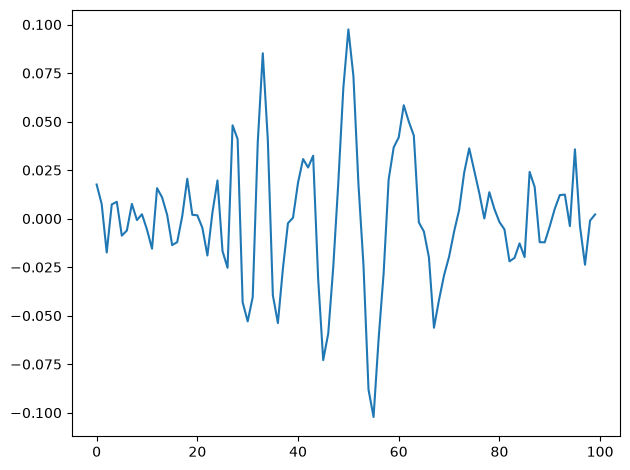

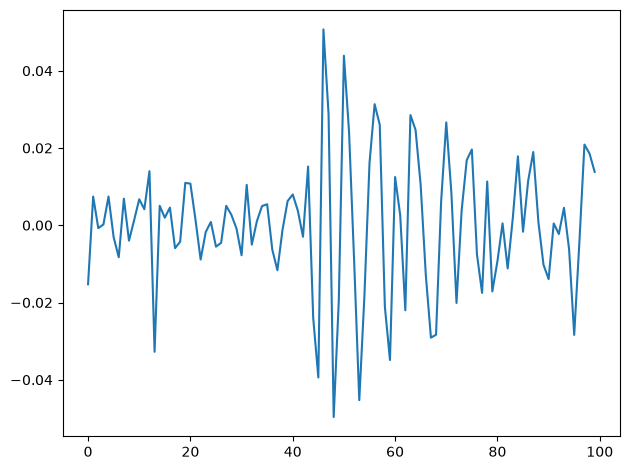

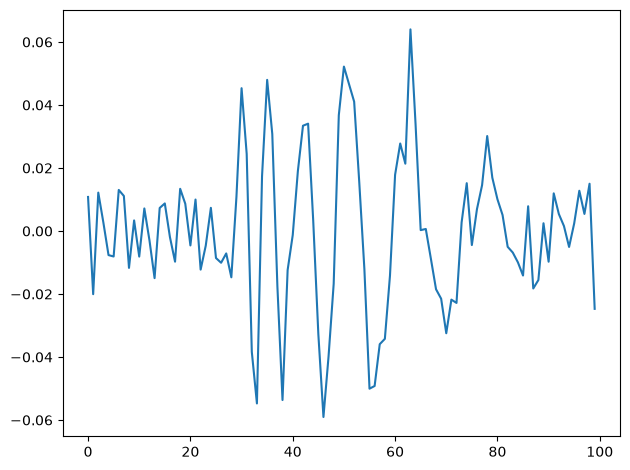

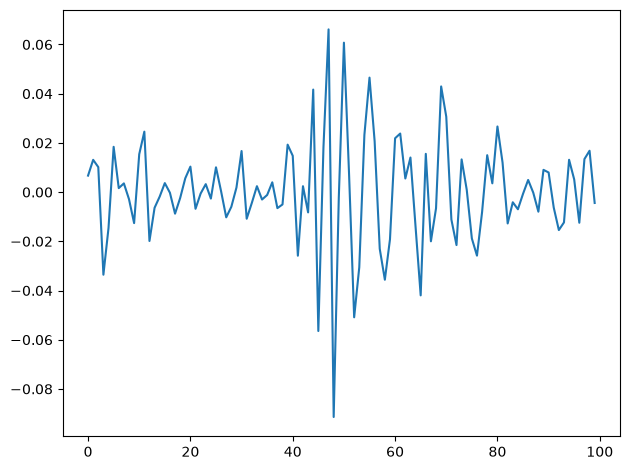

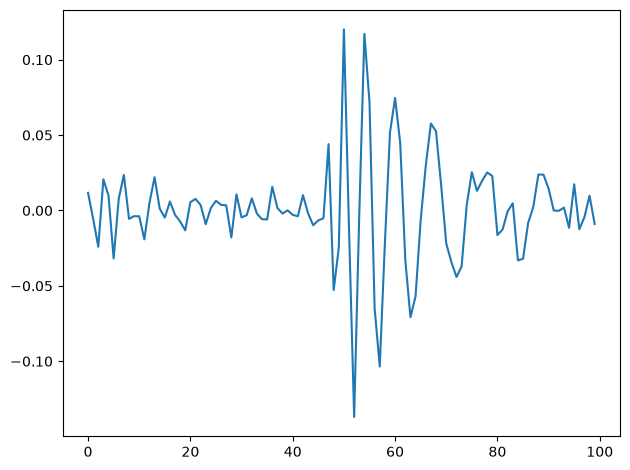

In [10]:
# plot a few signal events
for trace in x[smask][:5]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

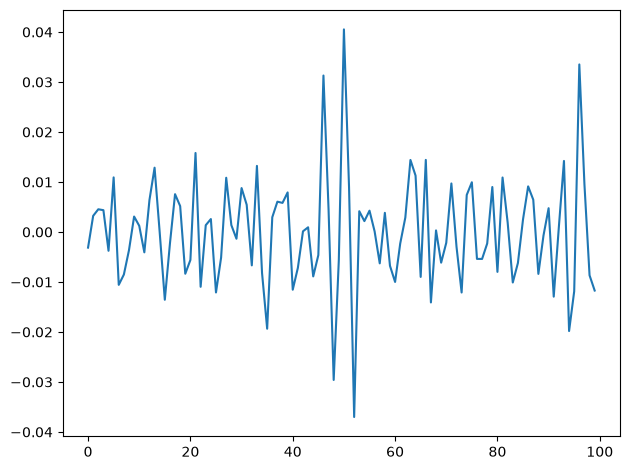

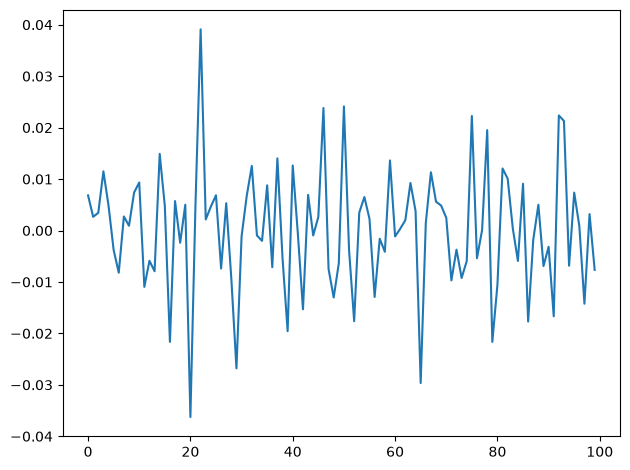

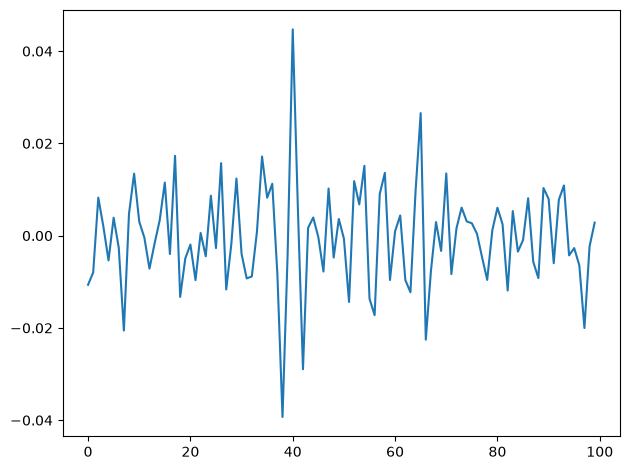

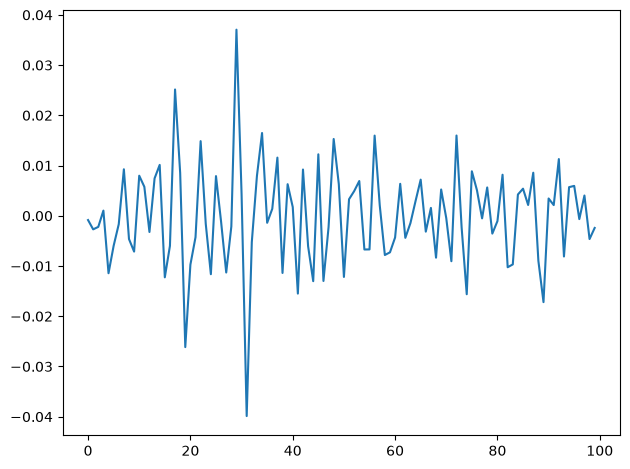

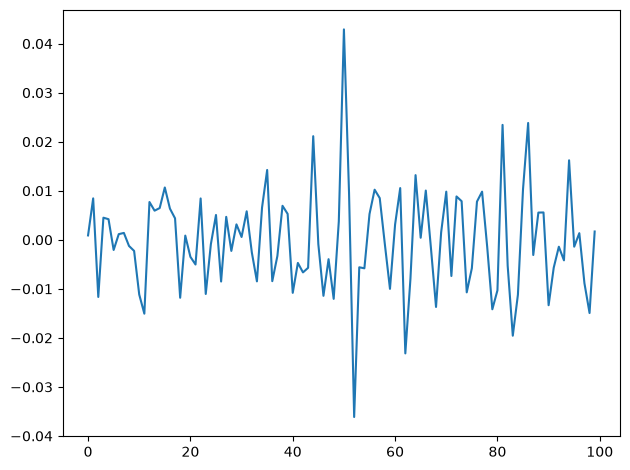

In [11]:
for trace in x[~smask][:5]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

The signal data seems to have regions with high intensity, while the noise plots have high amplitudes aver the full x-axis. But that also might just be because of the random five picks for each category. In the end I wouldn't trust myself to differentiate between signal and noise.

In [10]:
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

In [11]:
scaler = StandardScaler()

x_train_val_scaled = scaler.fit_transform(x_train_val)

x_test_scaled = scaler.transform(x_test)

In [14]:
model = Sequential(
    [
        keras.layers.Input(shape=x_train_val_scaled.shape[1:]),
        Dense(64, activation="swish"),
        Dense(32, activation="swish"),
        Dense(1, activation="sigmoid")
    ],
    name="simple_dense"
)
print(model.summary())

Model: "simple_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                6464      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 8577 (33.50 KB)
Trainable params: 8577 (33.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


2026-07-07 15:05:56.164008: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-07-07 15:05:56.164027: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-07 15:05:56.164031: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-07-07 15:05:56.164049: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-07 15:05:56.164059: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [15]:
csv_logger = keras.callbacks.CSVLogger('training_history.csv', append=False)


In [16]:
# model.compile(
#     optimizer=optimizer,
#     loss=keras.losses.BinaryCrossentropy(),
#     metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
# )

# model.fit(x_train_val_scaled, y_train_val, 
#           batch_size=32, 
#           epochs=20, 
#           validation_split=0.2,
#           callbacks=[csv_logger, keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)])

# model.save("simple_dense.h5")

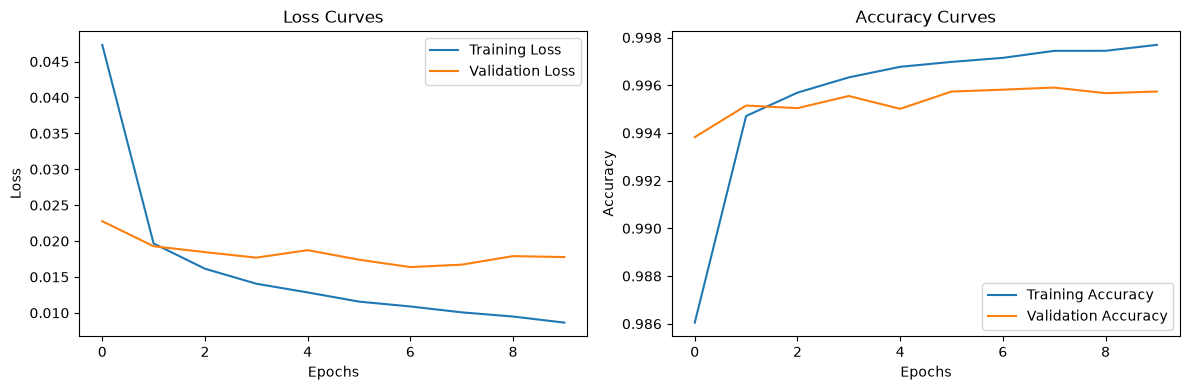

In [17]:
# plot loss and accuracy curves
df = pd.read_csv("training_history.csv")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df['loss'], label='Training Loss')
plt.plot(df['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(df['accuracy'], label='Training Accuracy')
plt.plot(df['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

In [43]:
# load model
model = keras.models.load_model("simple_dense.h5", compile=False)

Evaluating simple_dense...
2813/2813 [==============================] - 2s 766us/step


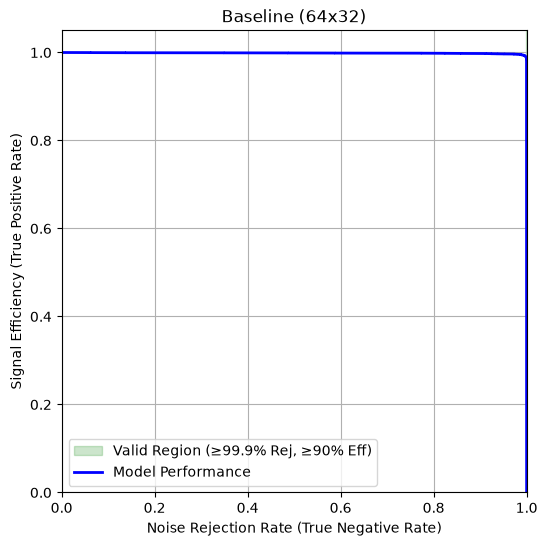

In [48]:
# Evaluate your baseline model
rej, eff, thresh = evaluate_model_performance(model, x_test_scaled, y_test, title="Baseline (64x32)", zoom=False)

The model performs extremely good. It is obvious that it doesn't need to be as big to still fullfil the rejection and efficiency criteria we set for it.

 160/2813 [>.............................] - ETA: 2s

2026-07-07 15:05:56.440511: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2813/2813 [==============================] - 2s 830us/step


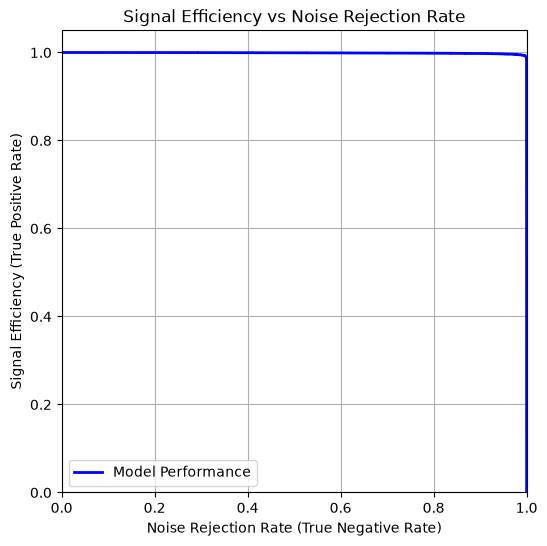

In [19]:
# Get predictions
y_pred_probs = model.predict(x_test_scaled).ravel()

# Let sklearn calculate the metrics for ALL thresholds automatically
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Translate to specific metrics
signal_efficiency = tpr              # True Positive Rate
noise_rejection = 1.0 - fpr          # True Negative Rate

# Plot the full curve
plt.figure(figsize=(6, 6))
# Plotting the arrays directly creates a line instead of a dot
plt.plot(noise_rejection, signal_efficiency, lw=2, color='blue', label='Model Performance')

plt.title('Signal Efficiency vs Noise Rejection Rate')
plt.xlabel('Noise Rejection Rate (True Negative Rate)')
plt.ylabel('Signal Efficiency (True Positive Rate)')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(loc="lower left")
plt.show()

In [20]:
# Calculate the total FLOPS for specific model
total_flops = get_flops(model)
print(f"Total FLOPS for one sample: {total_flops:,}")

# Define hardware's theoretical peak performance.
if platform.system() == "Darwin":
    # (Base M5 Estimate)
    print("💻 Mac detected: Using Apple M5 10-Core GPU specs (5.5 TFLOPS)")
    hardware_flops_per_second = 5.5 * 10**12  
else:
    # Desktop (AMD RX 6950 XT)
    print("🖥️ Desktop detected: Using AMD Radeon RX 6950 XT specs (23.65 TFLOPS)")
    hardware_flops_per_second = 23.65 * 10**12

# 3. Calculate estimated execution time in seconds
execution_time_seconds = total_flops / hardware_flops_per_second

# Convert to microseconds for easier reading, since your model is tiny
execution_time_microseconds = execution_time_seconds * 1_000_000

print(f"Estimated execution time (Compute Only): {execution_time_microseconds:.6f} microseconds")

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
Total FLOPS for one sample: 17,249
💻 Mac detected: Using Apple M5 10-Core GPU specs (5.5 TFLOPS)
Estimated execution time (Compute Only): 0.003136 microseconds

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select       

2026-07-07 15:05:59.290406: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-07-07 15:05:59.290461: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-07-07 15:05:59.290554: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-07 15:05:59.290564: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


The Estimated execution time is 0.003136 microseconds. This is already very small but let's see if I can push it down further.

In [21]:
# define a second, simpler model:
model_2 = Sequential(
    [
        keras.layers.Input(shape=x_train_val_scaled.shape[1:]),
        Dense(32, activation="swish"),
        Dense(16, activation="swish"),
        Dense(1, activation="sigmoid")
    ],
    name="simpler_dense"
)
print(model_2.summary())

Model: "simpler_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 32)                3232      
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3777 (14.75 KB)
Trainable params: 3777 (14.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [ ]:
csv_logger_2 = keras.callbacks.CSVLogger('training_history_2.csv', append=False)

In [22]:
model_2.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

model_2.fit(x_train_val_scaled, y_train_val, 
          batch_size=32, 
          epochs=20, 
          validation_split=0.2,
          callbacks=[csv_logger, keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)])

Epoch 1/20
12750/12750 [==============================] - 60s 5ms/step - loss: 0.0552 - accuracy: 0.9837 - val_loss: 0.0247 - val_accuracy: 0.9930
Epoch 2/20
12750/12750 [==============================] - 60s 5ms/step - loss: 0.0238 - accuracy: 0.9934 - val_loss: 0.0217 - val_accuracy: 0.9939
Epoch 3/20
12750/12750 [==============================] - 56s 4ms/step - loss: 0.0203 - accuracy: 0.9943 - val_loss: 0.0209 - val_accuracy: 0.9942
Epoch 4/20
12750/12750 [==============================] - 54s 4ms/step - loss: 0.0180 - accuracy: 0.9951 - val_loss: 0.0186 - val_accuracy: 0.9950
Epoch 5/20
12750/12750 [==============================] - 55s 4ms/step - loss: 0.0163 - accuracy: 0.9956 - val_loss: 0.0185 - val_accuracy: 0.9951
Epoch 6/20
12750/12750 [==============================] - 56s 4ms/step - loss: 0.0151 - accuracy: 0.9960 - val_loss: 0.0176 - val_accuracy: 0.9955
Epoch 7/20
12750/12750 [==============================] - 58s 5ms/step - loss: 0.0144 - accuracy: 0.9962 - val_loss: 0

2813/2813 [==============================] - 3s 898us/step


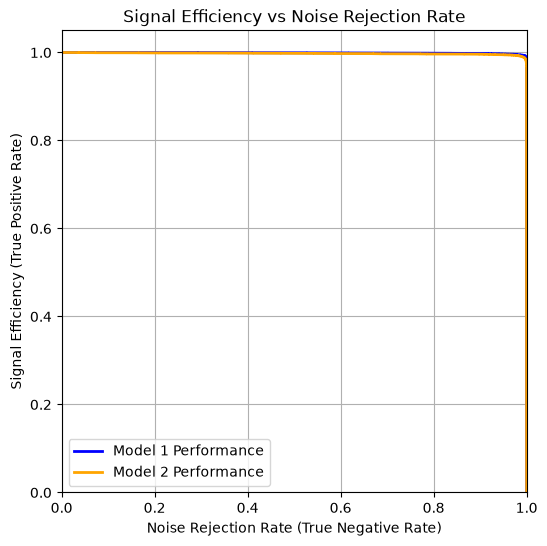

In [23]:
# get predictions for the second model
y_pred_probs_2 = model_2.predict(x_test_scaled).ravel()

fpr_2, tpr_2, thresholds_2 = roc_curve(y_test, y_pred_probs_2)

signal_efficiency_2 = tpr_2              # True Positive Rate
noise_rejection_2 = 1.0 - fpr_2          # True Negative

plt.figure(figsize=(6, 6))

plt.plot(noise_rejection, signal_efficiency, lw=2, color='blue', label='Model 1 Performance')
plt.plot(noise_rejection_2, signal_efficiency_2, lw=2, color='orange', label='Model 2 Performance')

plt.title('Signal Efficiency vs Noise Rejection Rate')
plt.xlabel('Noise Rejection Rate (True Negative Rate)')
plt.ylabel('Signal Efficiency (True Positive Rate)')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(loc="lower left")

In [12]:
model_3 = Sequential(
    [
        keras.layers.Input(shape=x_train_val_scaled.shape[1:]),
        Dense(16, activation="swish"),
        Dense(8, activation="swish"),
        Dense(1, activation="sigmoid")
    ],
    name="smallest_dense"
)
print(model_3.summary())

Model: "smallest_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                1616      
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1761 (6.88 KB)
Trainable params: 1761 (6.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


2026-07-08 10:42:30.624309: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-07-08 10:42:30.624340: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-08 10:42:30.624348: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-07-08 10:42:30.624544: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-08 10:42:30.624849: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [13]:
csv_logger_3 = keras.callbacks.CSVLogger('training_history_3.csv', append=False)

model_3.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

model_3.fit(x_train_val_scaled, y_train_val, 
          batch_size=32, 
          epochs=10, 
          validation_split=0.2,
          callbacks=[csv_logger_3, keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)])

Epoch 1/10


2026-07-08 10:43:40.197808: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


12750/12750 [==============================] - 56s 4ms/step - loss: 0.0698 - accuracy: 0.9789 - val_loss: 0.0358 - val_accuracy: 0.9895
Epoch 2/10
12750/12750 [==============================] - 53s 4ms/step - loss: 0.0321 - accuracy: 0.9909 - val_loss: 0.0308 - val_accuracy: 0.9911
Epoch 3/10
12750/12750 [==============================] - 53s 4ms/step - loss: 0.0285 - accuracy: 0.9920 - val_loss: 0.0281 - val_accuracy: 0.9918
Epoch 4/10
12750/12750 [==============================] - 54s 4ms/step - loss: 0.0257 - accuracy: 0.9928 - val_loss: 0.0261 - val_accuracy: 0.9927
Epoch 5/10
12750/12750 [==============================] - 57s 4ms/step - loss: 0.0240 - accuracy: 0.9934 - val_loss: 0.0252 - val_accuracy: 0.9930
Epoch 6/10
12750/12750 [==============================] - 61s 5ms/step - loss: 0.0224 - accuracy: 0.9938 - val_loss: 0.0231 - val_accuracy: 0.9936
Epoch 7/10
12750/12750 [==============================] - 54s 4ms/step - loss: 0.0215 - accuracy: 0.9941 - val_loss: 0.0229 - val

Evaluating smallest_dense...
2813/2813 [==============================] - 3s 928us/step


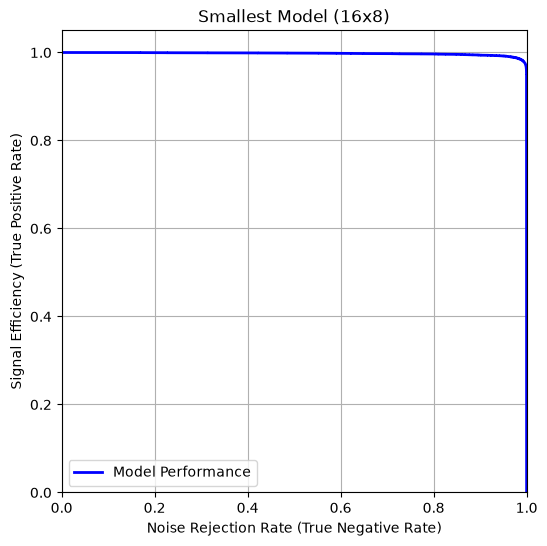

In [16]:
rej_3, eff_3, thresh_3 = evaluate_model_performance(model_3, x_test_scaled, y_test, title="Smallest Model (16x8)")

To get 99.90% Noise Rejection:
2813/2813 [==============================] - 3s 962us/step
Plotting distributions with threshold 0.6243157982826233...


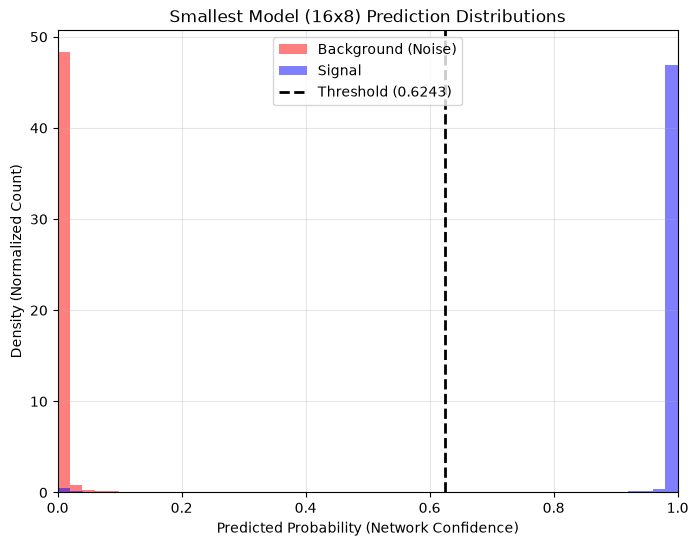

In [19]:
valid_indices = np.where(rej_3 >= 0.999)[0]


target_idx_3 = valid_indices[-1]

print(f"To get {rej_3[target_idx_3]:.2%} Noise Rejection:")

plot_prediction_histograms(y_test, model_3.predict(x_test_scaled).ravel(), threshold=thresh_3[target_idx_3], title="Smallest Model (16x8) Prediction Distributions")

In [36]:
model_regression = Sequential(
    [
        keras.layers.Input(shape=x_train_val_scaled.shape[1:]),
        Dense(6, activation="swish"),
        Dense(4, activation="swish"),
        Dense(1, activation="sigmoid")
    ],
    name="regression_dense"
)

print(model_regression.summary())

Model: "regression_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 6)                 606       
                                                                 
 dense_23 (Dense)            (None, 4)                 28        
                                                                 
 dense_24 (Dense)            (None, 1)                 5         
                                                                 
Total params: 639 (2.50 KB)
Trainable params: 639 (2.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [37]:
model_regression.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

csv_logger_regression = keras.callbacks.CSVLogger('training_history_regression.csv', append=False)

model_regression.fit(x_train_val_scaled, y_train_val,
            batch_size=32, 
            epochs=10, 
            validation_split=0.2,
            callbacks=[csv_logger_regression, keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)])

Epoch 1/10
12750/12750 [==============================] - 55s 4ms/step - loss: 0.0998 - accuracy: 0.9700 - val_loss: 0.0705 - val_accuracy: 0.9790
Epoch 2/10
12750/12750 [==============================] - 55s 4ms/step - loss: 0.0629 - accuracy: 0.9810 - val_loss: 0.0564 - val_accuracy: 0.9831
Epoch 3/10
12750/12750 [==============================] - 57s 5ms/step - loss: 0.0524 - accuracy: 0.9844 - val_loss: 0.0493 - val_accuracy: 0.9855
Epoch 4/10
12750/12750 [==============================] - 57s 4ms/step - loss: 0.0473 - accuracy: 0.9857 - val_loss: 0.0450 - val_accuracy: 0.9869
Epoch 5/10
12750/12750 [==============================] - 57s 4ms/step - loss: 0.0441 - accuracy: 0.9869 - val_loss: 0.0436 - val_accuracy: 0.9871
Epoch 6/10
12750/12750 [==============================] - 56s 4ms/step - loss: 0.0418 - accuracy: 0.9875 - val_loss: 0.0420 - val_accuracy: 0.9873
Epoch 7/10
12750/12750 [==============================] - 57s 4ms/step - loss: 0.0404 - accuracy: 0.9880 - val_loss: 0

Evaluating regression_dense...
2813/2813 [==============================] - 2s 883us/step


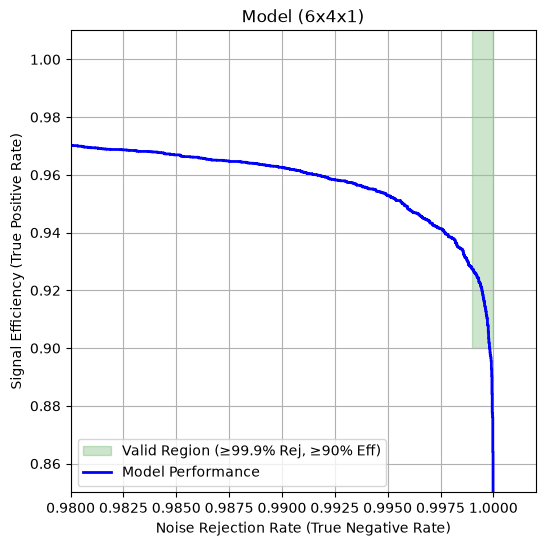

To get 99.90% Noise Rejection:
-> You need a threshold of 0.7004
2813/2813 [==============================] - 3s 955us/step
Plotting distributions with threshold 0.7003996968269348...


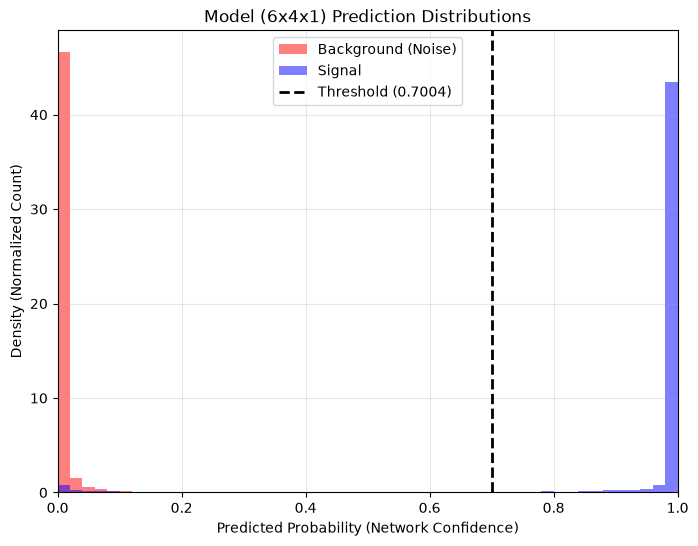

In [39]:
rej_reg, eff_reg, thresh_reg = evaluate_model_performance(model_regression, x_test_scaled, y_test, title="Model (6x4x1)")

valid_indices_reg = np.where(rej_reg >= 0.999)[0]

target_idx_reg = valid_indices_reg[-1]
print(f"To get {rej_reg[target_idx_reg]:.2%} Noise Rejection:")
print(f"-> You need a threshold of {thresh_reg[target_idx_reg]:.4f}")

plot_prediction_histograms(y_test, model_regression.predict(x_test_scaled).ravel(), threshold=thresh_reg[target_idx_reg], title="Model (6x4x1) Prediction Distributions")

This is the smallest network I found which still fulfills all posed criteria. As we can see in the noise rejection vs signal eff., it scrapes on the lower end of the allowed region, but still performs good enough.

In [51]:
total_flops_regression = get_flops(model_regression)
print(f"Total FLOPS for one sample: {total_flops_regression:,}")

hardware_flops_per_second = 5.5 * 10**12

execution_time_seconds_regression = total_flops_regression / hardware_flops_per_second

print(f"Estimated execution time (Compute Only): {execution_time_seconds_regression * 1_000_000:.6f} microseconds")

Total FLOPS for one sample: 1,287
=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Estimated execution time (Compute Only): 0.000234 microseconds

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are ag

2026-07-08 22:06:15.583665: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-07-08 22:06:15.583714: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-07-08 22:06:15.583843: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-08 22:06:15.583856: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


The number of FLOPS could be reduced from 17,249 to 1,287. This is less than 10% of the starting network.

The execution time is down to 0.000234 microseconds, which is also a bit more than an order of magnitude better.

In [40]:
model_smallest = Sequential(
    [
        keras.layers.Input(shape=x_train_val_scaled.shape[1:]),
        Dense(4, activation="swish"),
        Dense(2, activation="swish"),
        Dense(1, activation="sigmoid")
    ],
    name="smallest_dense"
)

In [41]:
model_smallest.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)


model_smallest.fit(x_train_val_scaled, y_train_val,
            batch_size=64, 
            epochs=20, 
            validation_split=0.2,
            callbacks=[keras.callbacks.CSVLogger('training_history_smallest.csv', append=False), keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)]
)

Epoch 1/20
6375/6375 [==============================] - 28s 4ms/step - loss: 0.1430 - accuracy: 0.9549 - val_loss: 0.0830 - val_accuracy: 0.9761
Epoch 2/20
6375/6375 [==============================] - 28s 4ms/step - loss: 0.0762 - accuracy: 0.9780 - val_loss: 0.0719 - val_accuracy: 0.9792
Epoch 3/20
6375/6375 [==============================] - 28s 4ms/step - loss: 0.0703 - accuracy: 0.9794 - val_loss: 0.0686 - val_accuracy: 0.9803
Epoch 4/20
6375/6375 [==============================] - 28s 4ms/step - loss: 0.0682 - accuracy: 0.9802 - val_loss: 0.0667 - val_accuracy: 0.9808
Epoch 5/20
6375/6375 [==============================] - 29s 4ms/step - loss: 0.0659 - accuracy: 0.9807 - val_loss: 0.0659 - val_accuracy: 0.9807
Epoch 6/20
6375/6375 [==============================] - 28s 4ms/step - loss: 0.0649 - accuracy: 0.9809 - val_loss: 0.0632 - val_accuracy: 0.9814
Epoch 7/20
6375/6375 [==============================] - 28s 4ms/step - loss: 0.0627 - accuracy: 0.9816 - val_loss: 0.0621 - val_ac

Evaluating smallest_dense...
2813/2813 [==============================] - 3s 922us/step


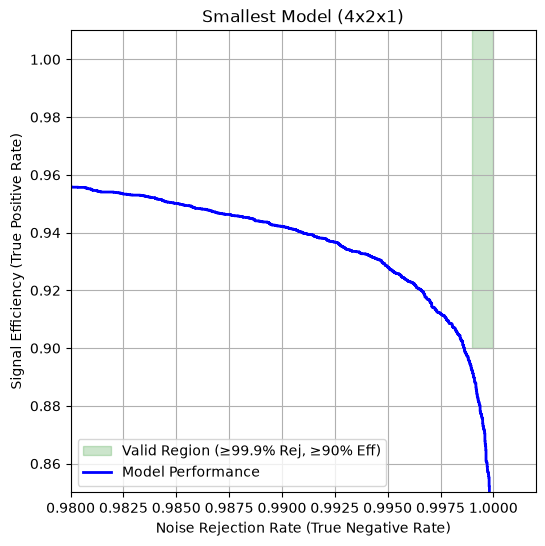

To get 99.90% Noise Rejection:
-> You need a threshold of 0.7885
2813/2813 [==============================] - 3s 926us/step
Plotting distributions with threshold 0.7885044813156128...


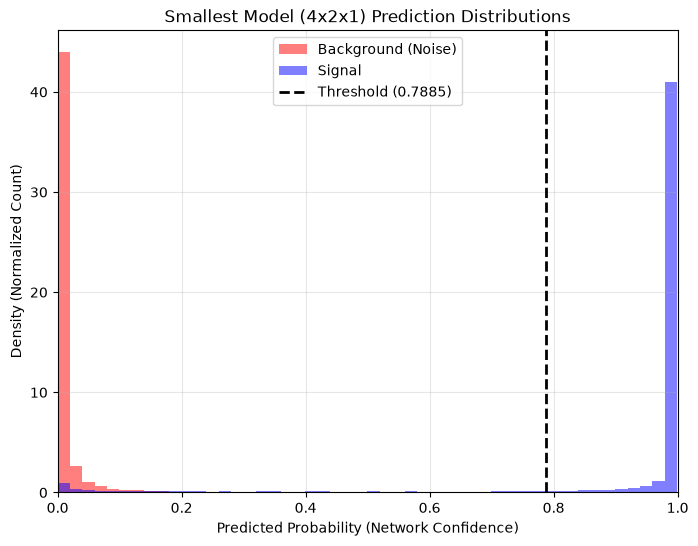

In [42]:
rej_smallest, eff_smallest, thresh_smallest = evaluate_model_performance(model_smallest, x_test_scaled, y_test, title="Smallest Model (4x2x1)")

valid_indices_smallest = np.where(rej_smallest >= 0.999)[0]

target_idx_smallest = valid_indices_smallest[-1]
print(f"To get {rej_smallest[target_idx_smallest]:.2%} Noise Rejection:")
print(f"-> You need a threshold of {thresh_smallest[target_idx_smallest]:.4f}")

plot_prediction_histograms(y_test, model_smallest.predict(x_test_scaled).ravel(), threshold=thresh_smallest[target_idx_smallest], title="Smallest Model (4x2x1) Prediction Distributions")

While I am still impressed with the network with so few parameters performing this well, it sadly missed the mark by a bit. possibly there could be some slight tweaks to further improve it but the previous model is also already quite small.

One further improvement could be to switch to a ReLu activation, but on my macbook that lead to unpredictable behavior in training and a consistently growing loss with each epoch.